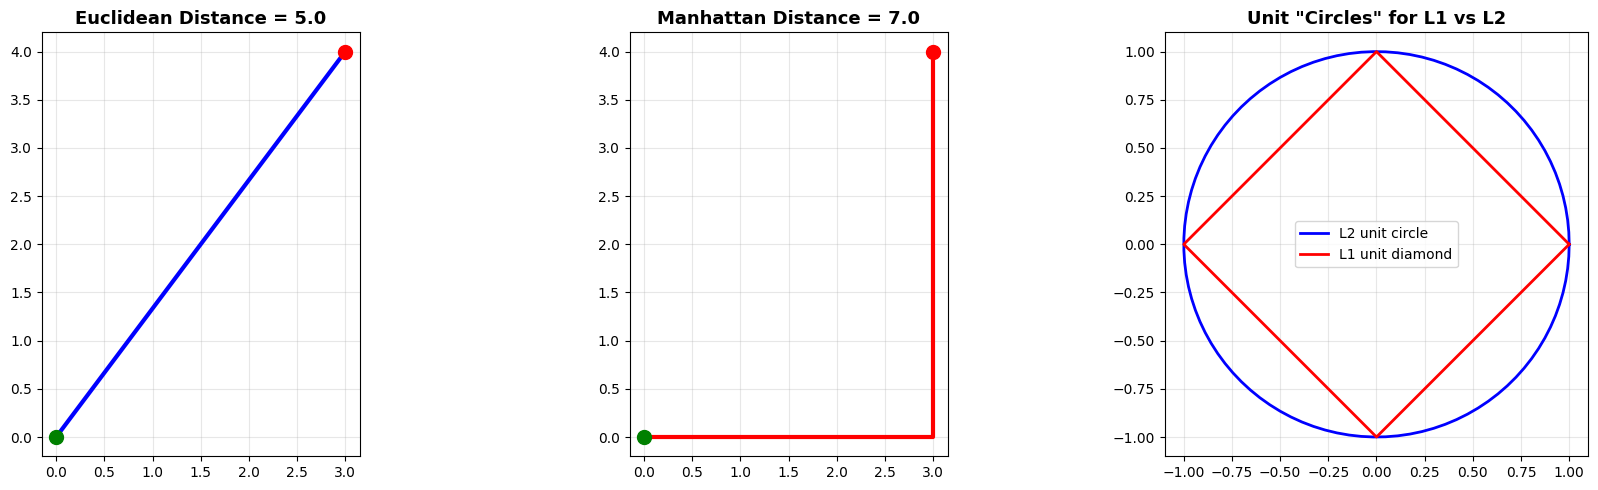

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Visualize different distance metrics in 2D
point = np.array([0, 0])
target = np.array([3, 4])

# L1 path (Manhattan)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Euclidean
axes[0].plot([0, 3], [0, 4], 'b-', linewidth=3)
axes[0].plot(0, 0, 'go', markersize=10)
axes[0].plot(3, 4, 'ro', markersize=10)
d = np.sqrt(3**2 + 4**2)
axes[0].set_title(f'Euclidean Distance = {d:.1f}', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_aspect('equal')

# Manhattan
axes[1].plot([0, 3, 3], [0, 0, 4], 'r-', linewidth=3)
axes[1].plot(0, 0, 'go', markersize=10)
axes[1].plot(3, 4, 'ro', markersize=10)
d = abs(3) + abs(4)
axes[1].set_title(f'Manhattan Distance = {d:.1f}', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_aspect('equal')

# Equidistant circles vs diamonds
theta = np.linspace(0, 2*np.pi, 100)
axes[2].plot(np.cos(theta), np.sin(theta), 'b-', linewidth=2, label='L2 unit circle')
diamond = np.array([[1,0],[0,1],[-1,0],[0,-1],[1,0]])
axes[2].plot(diamond[:,0], diamond[:,1], 'r-', linewidth=2, label='L1 unit diamond')
axes[2].set_title('Unit "Circles" for L1 vs L2', fontsize=13, fontweight='bold')
axes[2].set_aspect('equal')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('distance_metrics.png', dpi=150)
plt.show()

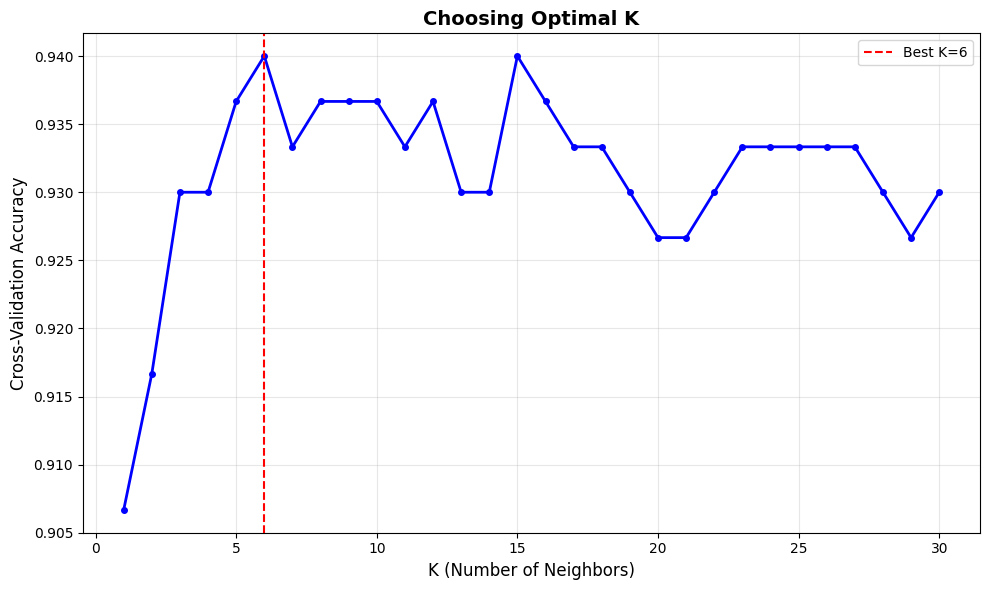

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score

X, y = make_classification(n_samples=300, n_features=10, random_state=42)

k_values = range(1, 31)
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X, y, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

best_k = k_values[np.argmax(cv_scores)]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(k_values, cv_scores, 'bo-', linewidth=2, markersize=4)
ax.axvline(best_k, color='red', linestyle='--', label=f'Best K={best_k}')
ax.set_xlabel('K (Number of Neighbors)', fontsize=12)
ax.set_ylabel('Cross-Validation Accuracy', fontsize=12)
ax.set_title('Choosing Optimal K', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('choosing_k.png', dpi=150)
plt.show()

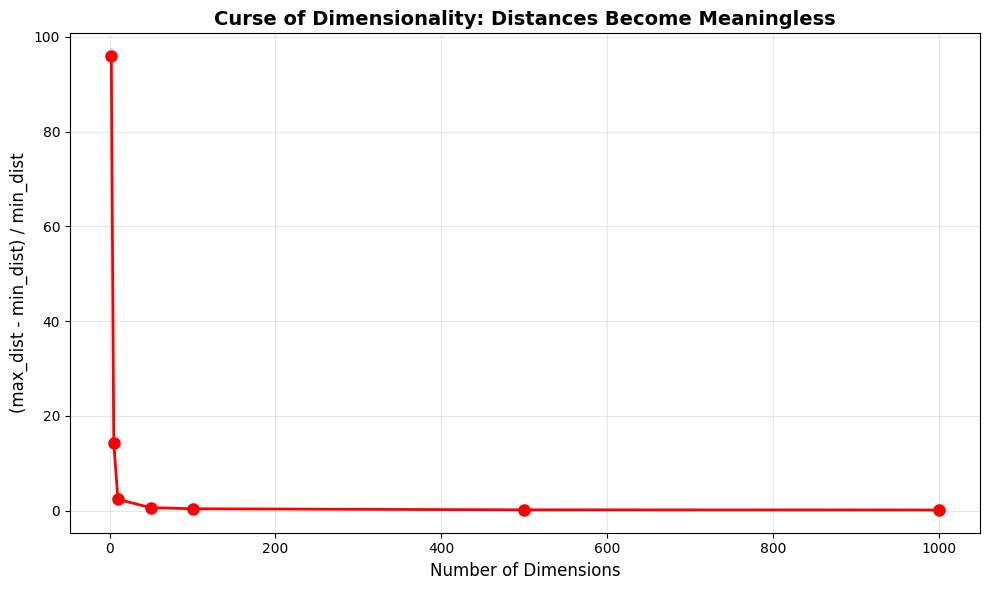

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Demonstrate curse of dimensionality
dims = [2, 5, 10, 50, 100, 500, 1000]
n_points = 1000
ratios = []

for d in dims:
    points = np.random.uniform(0, 1, (n_points, d))
    query = np.random.uniform(0, 1, d)
    distances = np.linalg.norm(points - query, axis=1)
    ratio = (distances.max() - distances.min()) / distances.min()
    ratios.append(ratio)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(dims, ratios, 'ro-', linewidth=2, markersize=8)
ax.set_xlabel('Number of Dimensions', fontsize=12)
ax.set_ylabel('(max_dist - min_dist) / min_dist', fontsize=12)
ax.set_title('Curse of Dimensionality: Distances Become Meaningless', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('curse_of_dimensionality.png', dpi=150)
plt.show()

In [5]:
from sklearn.neighbors import KNeighborsClassifier

# Uniform weights (default)
knn_uniform = KNeighborsClassifier(n_neighbors=5, weights='uniform')

# Distance weights (closer neighbors have more influence)
knn_weighted = KNeighborsClassifier(n_neighbors=5, weights='distance')

In [6]:
import numpy as np
from collections import Counter

class KNNFromScratch:
    def __init__(self, k=5, metric='euclidean'):
        self.k = k
        self.metric = metric
    
    def fit(self, X, y):
        self.X_train = np.array(X)
        self.y_train = np.array(y)
        return self
    
    def _distance(self, x1, x2):
        if self.metric == 'euclidean':
            return np.sqrt(np.sum((x1 - x2) ** 2))
        elif self.metric == 'manhattan':
            return np.sum(np.abs(x1 - x2))
    
    def predict(self, X):
        X = np.array(X)
        predictions = []
        for x in X:
            # Compute distances to all training points
            distances = [self._distance(x, x_train) for x_train in self.X_train]
            # Get K nearest neighbor indices
            k_indices = np.argsort(distances)[:self.k]
            k_labels = self.y_train[k_indices]
            # Majority vote
            most_common = Counter(k_labels).most_common(1)
            predictions.append(most_common[0][0])
        return np.array(predictions)
    
    def score(self, X, y):
        return np.mean(self.predict(X) == y)

# Test
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

knn = KNNFromScratch(k=5)
knn.fit(X_train_s, y_train)
print(f"From-scratch accuracy: {knn.score(X_test_s, y_test):.2%}")

From-scratch accuracy: 100.00%


In [7]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import classification_report

data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=7, weights='distance', metric='euclidean')
knn.fit(X_train_s, y_train)

print(f"Accuracy: {knn.score(X_test_s, y_test):.4f}")
print(f"\n{classification_report(y_test, knn.predict(X_test_s), target_names=data.target_names)}")

Accuracy: 0.9474

              precision    recall  f1-score   support

   malignant       0.93      0.93      0.93        43
      benign       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



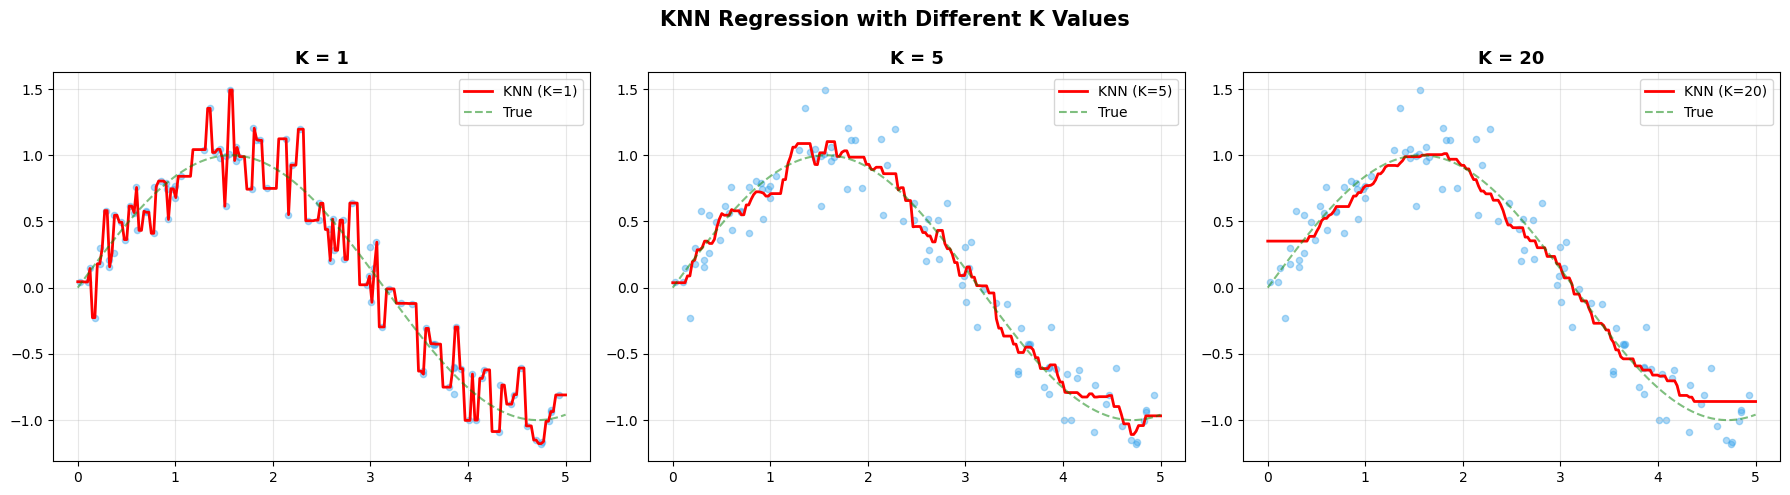

In [8]:
from sklearn.neighbors import KNeighborsRegressor
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
X = np.sort(np.random.uniform(0, 5, 100)).reshape(-1, 1)
y = np.sin(X.ravel()) + np.random.randn(100) * 0.2

X_plot = np.linspace(0, 5, 200).reshape(-1, 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, k in zip(axes, [1, 5, 20]):
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X, y)
    y_pred = model.predict(X_plot)
    
    ax.scatter(X, y, alpha=0.4, s=20, color='#36A2EB')
    ax.plot(X_plot, y_pred, 'r-', linewidth=2, label=f'KNN (K={k})')
    ax.plot(X_plot, np.sin(X_plot.ravel()), 'g--', alpha=0.5, label='True')
    ax.set_title(f'K = {k}', fontsize=13, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('KNN Regression with Different K Values', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('knn_regression.png', dpi=150)
plt.show()